# (b) 2D Representation of MNIST using PCA

The MNIST dataset contains 28 × 28 grayscale images of handwritten digits. Each image is represented as a 784-dimensional vector. The pixel values are normalized to [0, 1] before applying PCA.

Here, the first two principal components are used to represent the images in 2D.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

## Load the MNIST Dataset

The MNIST dataset is stored in IDX format. The image files contain the 28 × 28 pixel values and the label files contain the corresponding digit labels.

In [2]:
# Path to MNIST dataset
DATA_DIR = Path("data/mnist")

train_images_path = DATA_DIR / "train-images.idx3-ubyte"
train_labels_path = DATA_DIR / "train-labels.idx1-ubyte"

test_images_path = DATA_DIR / "t10k-images.idx3-ubyte"
test_labels_path = DATA_DIR / "t10k-labels.idx1-ubyte"

print(train_images_path)
print(test_images_path)

data\mnist\train-images.idx3-ubyte
data\mnist\t10k-images.idx3-ubyte


In [3]:
def load_mnist_images(path):
    """Load MNIST images from an IDX3-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_images = int.from_bytes(f.read(4), byteorder="big")
        n_rows = int.from_bytes(f.read(4), byteorder="big")
        n_cols = int.from_bytes(f.read(4), byteorder="big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    images = data.reshape(n_images, n_rows * n_cols)
    return images

def load_mnist_labels(path):
    """Load MNIST labels from an IDX1-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_labels = int.from_bytes(f.read(4), byteorder="big")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [4]:
# Load training data
X_train = load_mnist_images(train_images_path)
y_train = load_mnist_labels(train_labels_path)

# Load test data
X_test = load_mnist_images(test_images_path)
y_test = load_mnist_labels(test_labels_path)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 784)
Training labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


## Normalize Pixel Values

The original pixel values range from 0 to 255. They are divided by 255 to bring them to the range [0, 1].

In [5]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Apply PCA

PCA is fitted on the training data using the first two principal components.

In [6]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print("Training PCA representation:", X_train_pca.shape)

Training PCA representation: (60000, 2)


## (i) Variance explained by PC1, PC2 and their cummulative variance

In [7]:
explained_variance = pca.explained_variance_ratio_

pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]
cumulative_variance = explained_variance.sum()

print(f"PC1 variance explained: {pc1_variance:.4f} ({pc1_variance * 100:.2f}%)")
print(f"PC2 variance explained: {pc2_variance:.4f} ({pc2_variance * 100:.2f}%)")
print(f"Cumulative variance: {cumulative_variance:.4f} ({cumulative_variance * 100:.2f}%)")

PC1 variance explained: 0.0970 (9.70%)
PC2 variance explained: 0.0710 (7.10%)
Cumulative variance: 0.1680 (16.80%)


## (ii) Project MNIST Test images onto the PCA Space

The PCA model fitted on the training data is used to project the test images into the same 2D space.

In [8]:
X_test_pca = pca.transform(X_test)

print("Test PCA representation:", X_test_pca.shape)

Test PCA representation: (10000, 2)


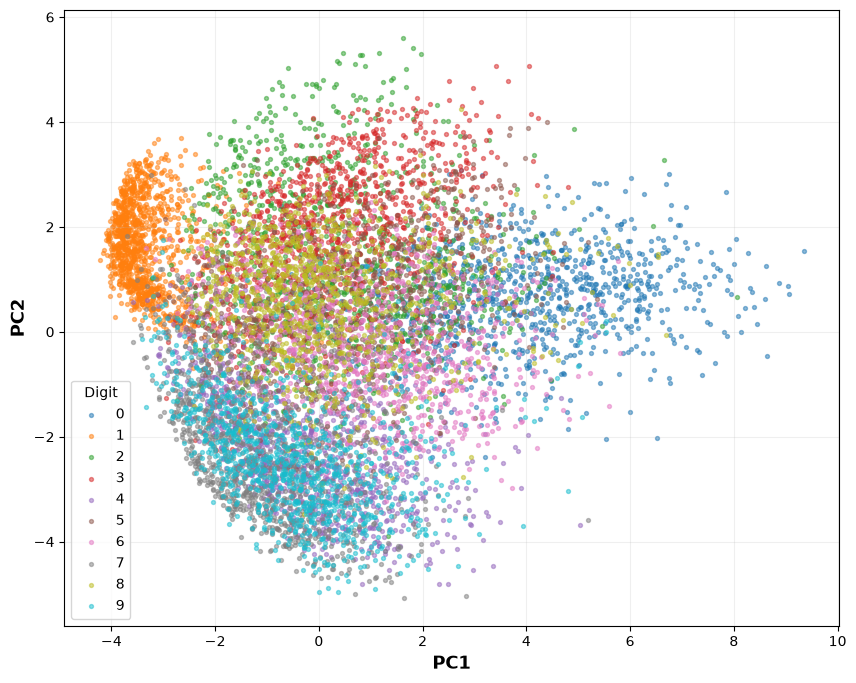

In [9]:
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_test == digit
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], s=8, alpha=0.5, label=str(digit))
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

## (iii) Selected Samples from Each Digit Class

200 test samples are selected from each digit class, giving 2000 samples in total. These samples are used for the reconstruction error, while 10 samples from each digit are shown in the reconstruction plots.

In [10]:
np.random.seed(11009)

samples_per_class = 200
selected_indices = []

for digit in range(10):
    indices = np.where(y_test == digit)[0]
    selected = np.random.choice(indices, size=samples_per_class, replace=False)
    selected_indices.extend(selected)
selected_indices = np.array(selected_indices)
X_selected = X_test[selected_indices]
y_selected = y_test[selected_indices]
X_selected_pca = X_test_pca[selected_indices]
print("Selected samples:", len(selected_indices))

Selected samples: 2000


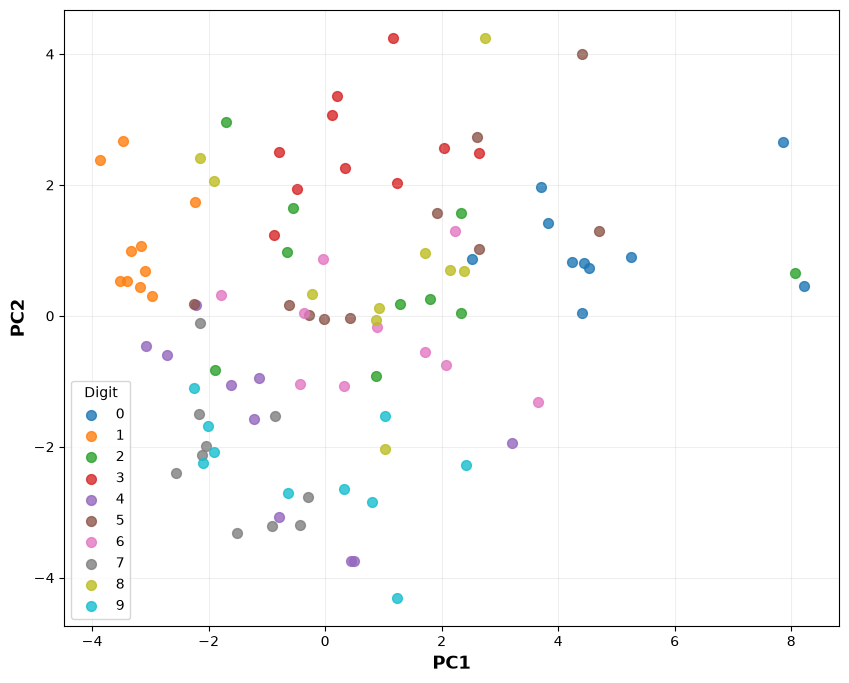

In [11]:
samples_to_plot = []
for digit in range(10):
    indices = np.where(y_selected == digit)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    samples_to_plot.extend(selected)
samples_to_plot = np.array(samples_to_plot)

X_plot_pca = X_selected_pca[samples_to_plot]
y_plot = y_selected[samples_to_plot]
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_plot == digit
    plt.scatter(X_plot_pca[mask, 0], X_plot_pca[mask, 1], s=50, alpha=0.8, label=str(digit))
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

### Observations

The PCA plot shows that some digits are more separated than others. Digit 1 is relatively well separated from many of the other digits. There is more overlap among several of the other classes, especially for digits with similar shapes such as 2, 3, 5, 8, etc. This is expected because PCA uses the overall variation in the images and does not use the digit labels when finding the principal components.

## (iv) Reconstruction Using the First Two Principal Components

The 2000 selected test images are reconstructed using only PC1 and PC2. For each digit, 10 original images are shown together with their corresponding reconstructed images to compare the information that is retained and lost

In [12]:
X_original = X_selected.copy()
X_selected_pca = pca.transform(X_original)
X_reconstructed = pca.inverse_transform(X_selected_pca)
X_reconstructed = np.clip(X_reconstructed, 0, 1)

print("Original:", X_original.shape)
print("PCA:", X_selected_pca.shape)
print("Reconstructed:", X_reconstructed.shape)

Original: (2000, 784)
PCA: (2000, 2)
Reconstructed: (2000, 784)


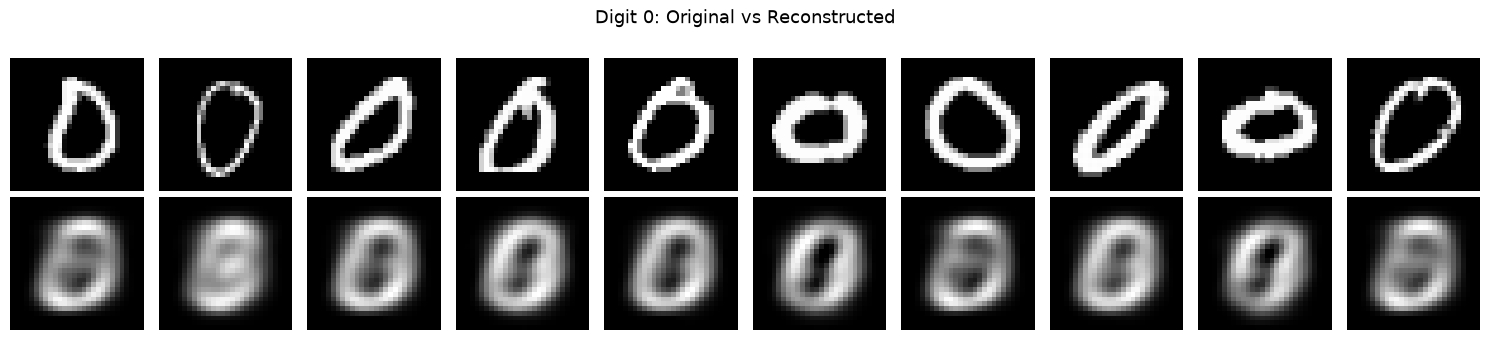

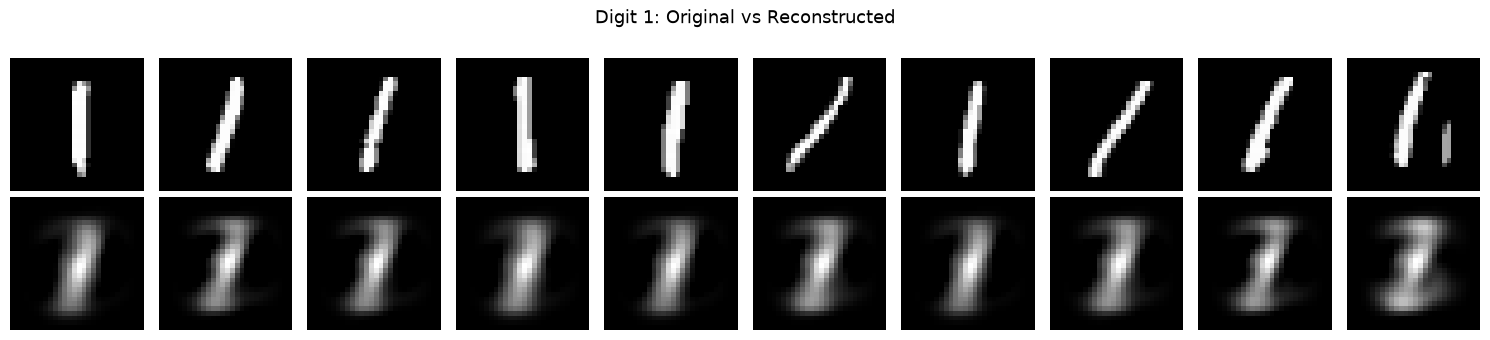

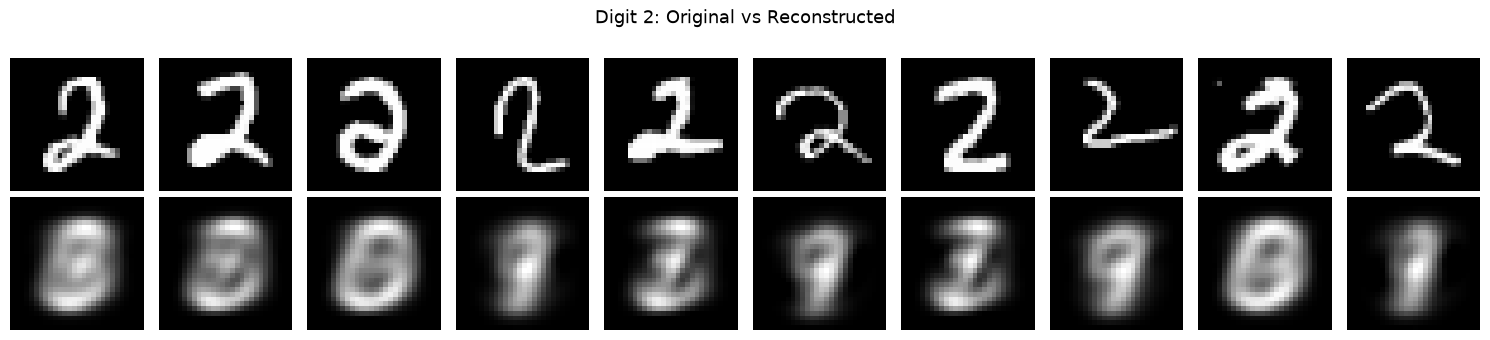

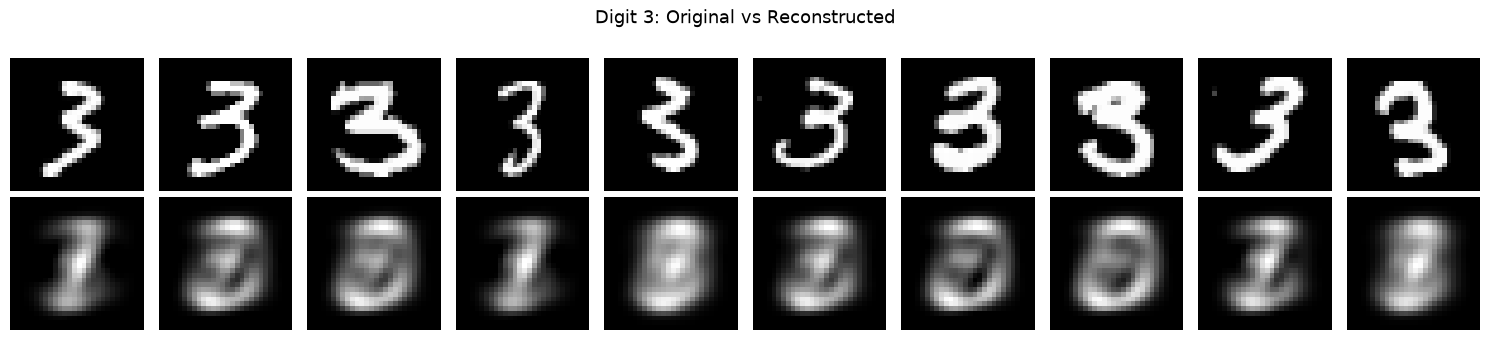

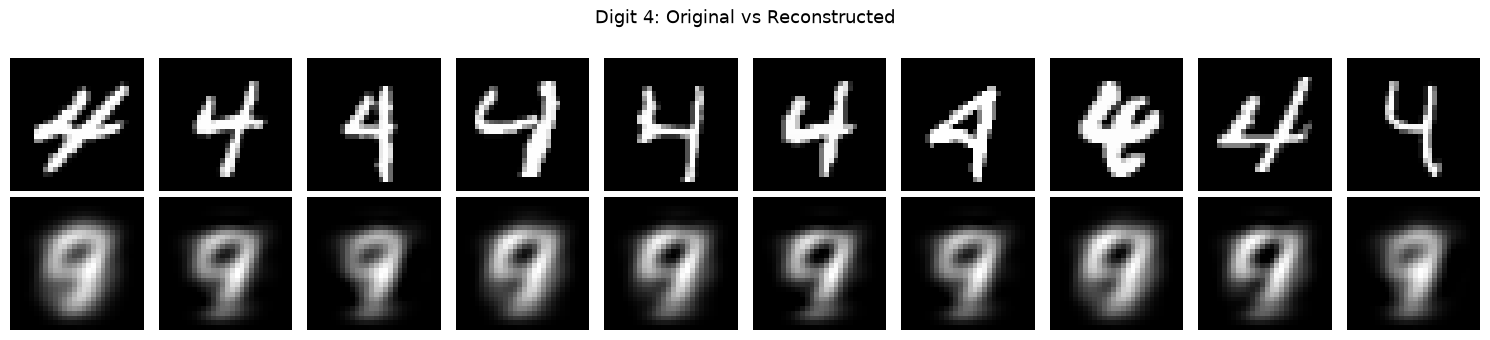

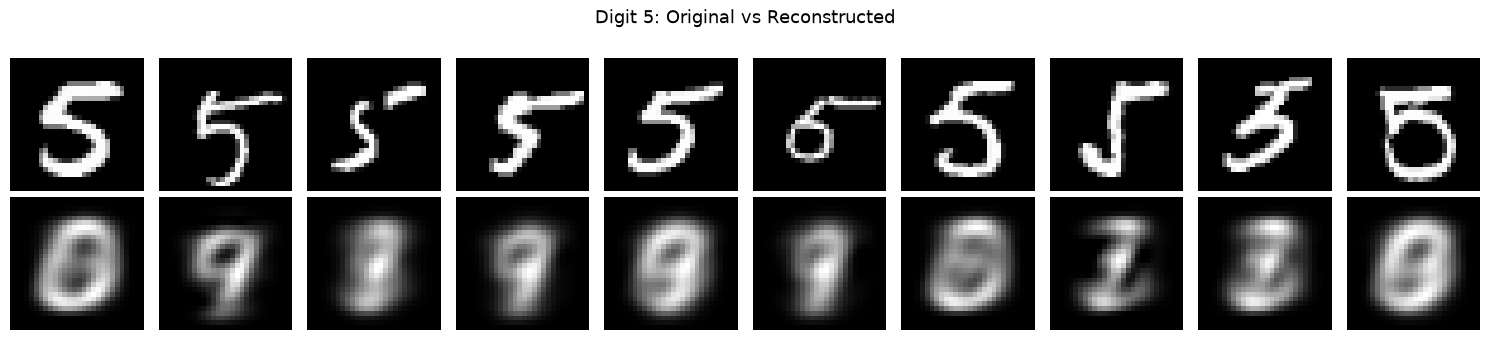

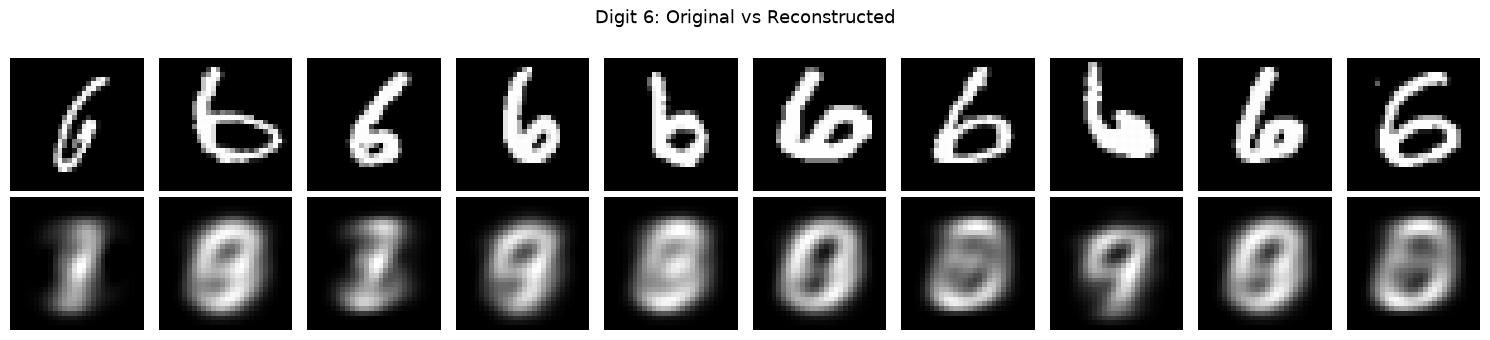

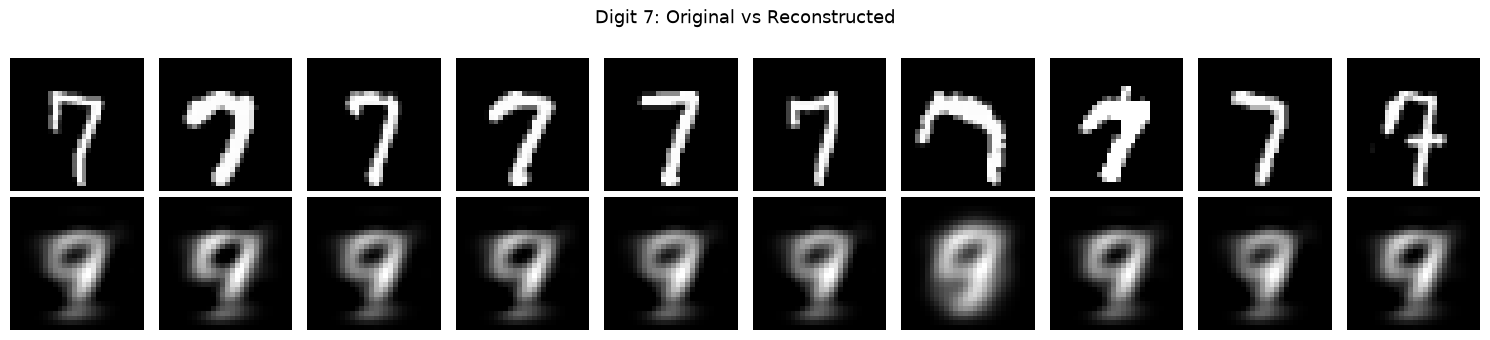

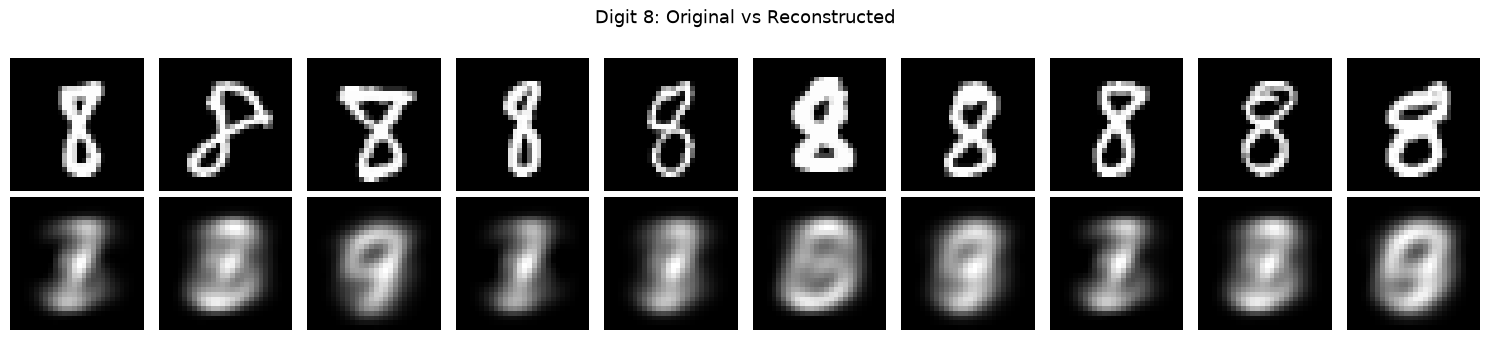

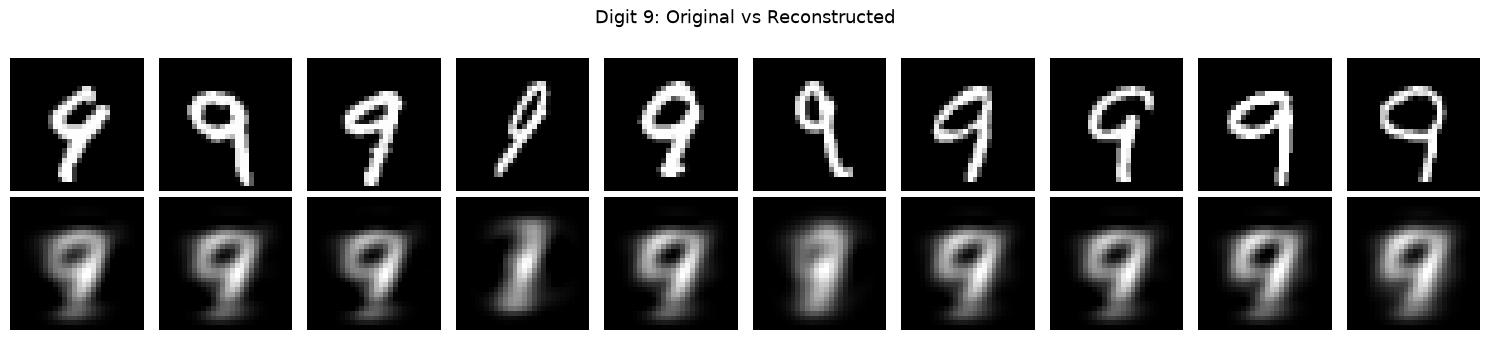

In [13]:
for digit in range(10):
    indices = np.where(y_selected == digit)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    for j, idx in enumerate(selected):
        axes[0, j].imshow(X_original[idx].reshape(28, 28),cmap="gray")
        axes[0, j].axis("off")
        axes[1, j].imshow(X_reconstructed[idx].reshape(28, 28),cmap="gray")
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
    fig.suptitle(f"Digit {digit}: Original vs Reconstructed",fontsize=13)
    plt.tight_layout()
    plt.show()

### Reconstruction Discussion

The reconstructed images usually preserve the general shape of the digit, but they are much more blurred than the original images. Digit 1 is generally easy to recognize after reconstruction, and many of the 0s are also recognizable. However, several samples from digits 2, 3, 4, 5, 6, 7, 8 are not very clear and can look like other digits. Digit 4 is particularly difficult to recognize in some of the reconstructed samples. This happens because only two principal components are used to reconstruct the original 784-dimensional images, so a large amount of the image detail is lost.

In [14]:
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(X_selected, X_reconstructed)
print(f"Mean Squared Reconstruction Error: {reconstruction_error:.3f}")

Mean Squared Reconstruction Error: 0.056


# (c) Analysis and Interpretation

## (i) Class Separation and Overlap

The 2D PCA plot shows that some digit classes are more separated than others. Digit 1 is relatively well separated from many of the other classes. There is more overlap between several of the remaining digits, particularly among digits such as 2, 3, 5 and 8. This is because some digits have similar shapes and PCA is not trying to separate the classes. It only finds the directions with the highest variance in the data.

## (ii) Usefulness of the First Two Principal Components

PC1 explains 9.70% of the variance and PC2 explains 7.10%, giving a cumulative explained variance of 16.80%. Even though the first two components capture only a small part of the total variance, they are still useful for visualization. They reduce the original 784 dimensions to two dimensions and allow the overall distribution and overlap between the digit classes to be seen in a single plot.

## (iii) Information Lost During Dimensionality Reduction

Using only two principal components means that 83.20% of the variance is not represented in the 2D representation. The reconstruction plots show the effect of this information loss. The general shape of many digits is still present, but the reconstructed images are blurred and some individual digits are difficult to recognize. Digit 1 is generally preserved better, while several samples of digits 2, 3, 4, 5, 6, 7, and 8 are less clear. In particular, some reconstructed 4s look closer to 7s or 9s. The mean squared reconstruction error over the 2000 selected test images is 0.056, which also shows that a considerable amount of information is lost when the 784-dimensional images are represented using only two principal components.